1. Identified high correlated columns
2. Scaling
3. Balanced the data
4. Forward selection step with logistic regression

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from imblearn.over_sampling import SMOTE
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_excel(r"D:\CRG\Diageo\For Python.xlsx")

df['Quality'] = df['Quality'].map({'Yes': 1, 'No': 0})

In [3]:
df.columns

Index(['Mash B#', 'Malt Hot Water Extract 6-Row (pct w by w)',
       'Malt Predicted Spirit Yield 6-Row (LA by T',
       'Malt Grist Ratio - Coarse (pct w by w)',
       'Malt Grist Ratio - Medium (pct w by w)',
       'Malt Grist Ratio - Fine (pct w by w)', 'Malt Moisture (pct)',
       'Malt Friability 6-Row', 'Water Sensory', 'Water pH', 'Water TDS',
       'Water Hardness', 'Water Chloride', 'Water Alkalinity',
       'Grist Quantity', 'Sparging Temperature 1', 'Sparging Temperature 2',
       'Mash Vessel Turnaround Time', 'Weak Wort Temperature',
       'Raking Arms Speed', 'Mashing - Striking Temp.', 'Draff Loss',
       'Resting Time', 'Wort Collection - Flow Rate',
       'First Wort Collection - Turbidity', 'First Wort Collection - Gravity',
       'Ferm. Yeast Addition', 'CIP Caustic Strength pct',
       'CIP Solution Temperature', 'CIP Circulation time',
       'CIP FV Contact Time', 'Yeast Culture Vessel-Wort Initial Gravity',
       'Yeast Culture Vessel-Wort Final Gra

In [4]:
correlation_matrix = df.corr()

print(correlation_matrix)

                                             Mash B#  \
Mash B#                                     1.000000   
Malt Hot Water Extract 6-Row (pct w by w)  -0.044718   
Malt Predicted Spirit Yield 6-Row (LA by T -0.044718   
Malt Grist Ratio - Coarse (pct w by w)      0.107222   
Malt Grist Ratio - Medium (pct w by w)      0.095535   
Malt Grist Ratio - Fine (pct w by w)       -0.138195   
Malt Moisture (pct)                         0.303391   
Malt Friability 6-Row                       0.052154   
Water Sensory                                    NaN   
Water pH                                    0.374014   
Water TDS                                   0.782777   
Water Hardness                             -0.437165   
Water Chloride                              0.588464   
Water Alkalinity                           -0.643227   
Grist Quantity                                   NaN   
Sparging Temperature 1                      0.093482   
Sparging Temperature 2                      0.07

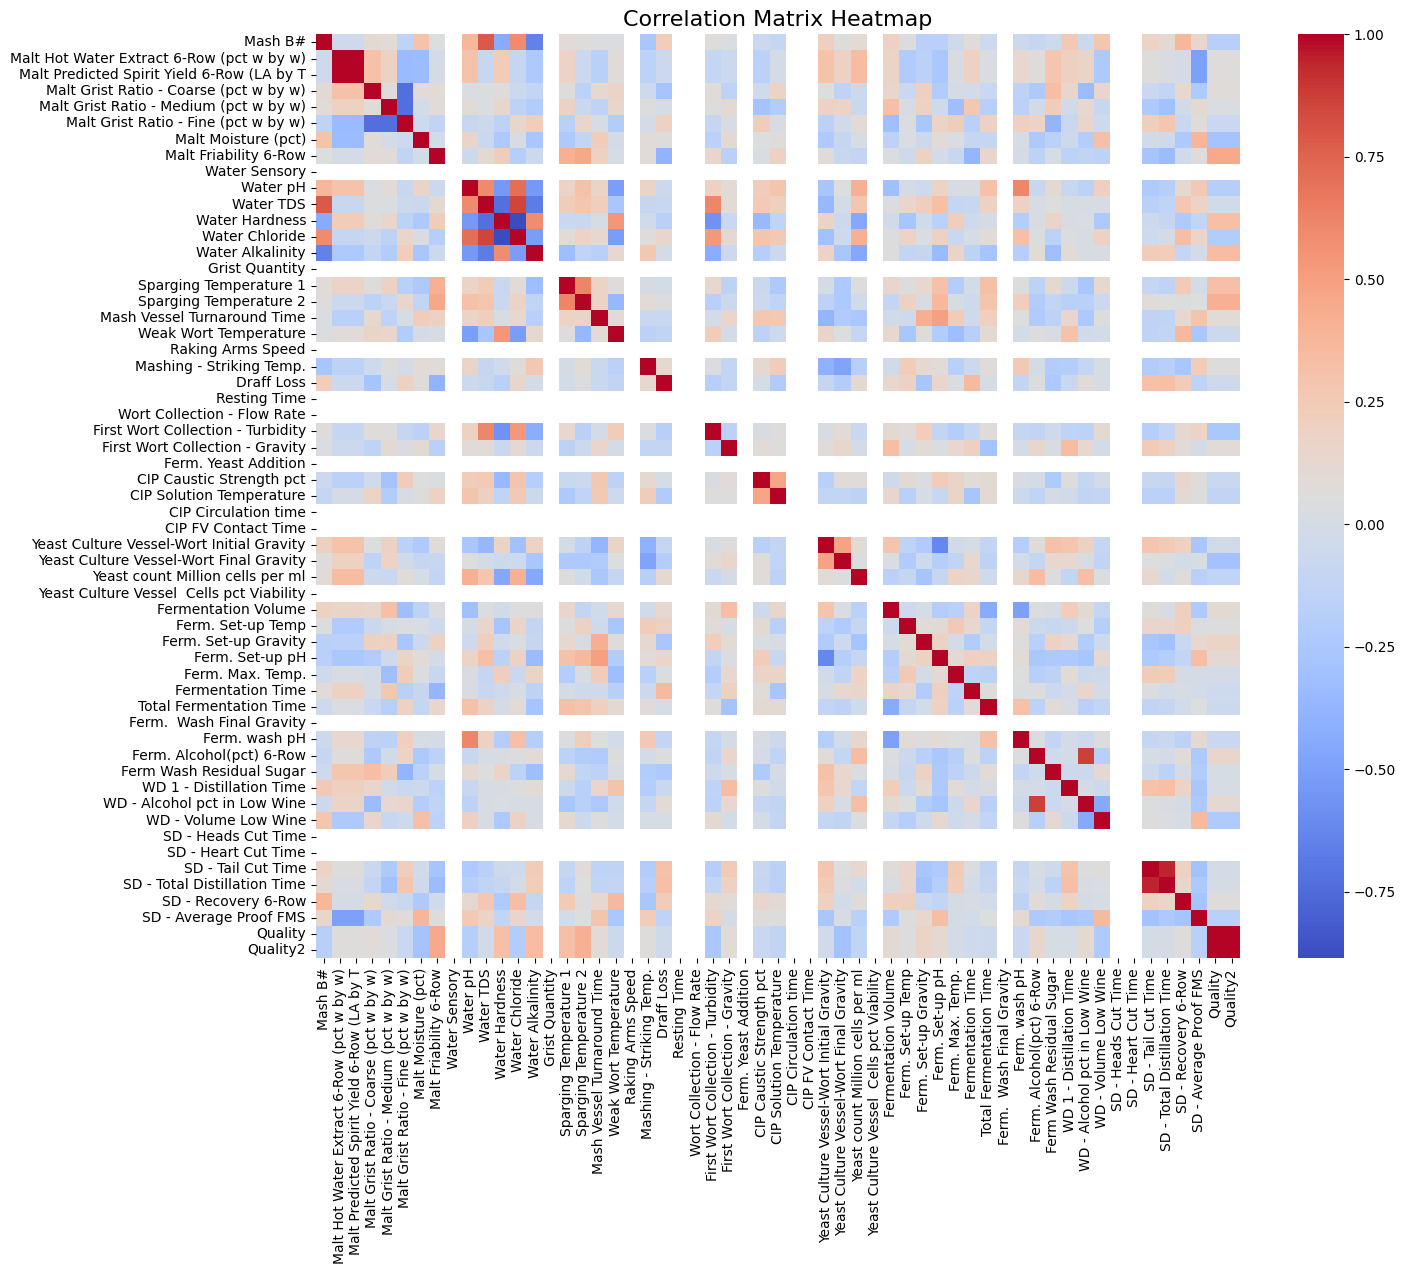

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 12))  # Adjust the size as needed
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', square=True, cbar=True)
plt.title('Correlation Matrix Heatmap', fontsize=16)
plt.show()

In [6]:
threshold = 0.2

highly_correlated_with_quality = []
for column in correlation_matrix.columns:
    if column != 'quality':
        correlation_value = correlation_matrix.loc['Quality', column]
        if abs(correlation_value) > threshold:
            highly_correlated_with_quality.append((column, correlation_value))

highly_correlated_with_quality_df = pd.DataFrame(highly_correlated_with_quality, columns=['Feature', 'Correlation with Quality'])

print("Highly correlated features with 'quality' (correlation > 0.2):")
print(highly_correlated_with_quality_df)

Highly correlated features with 'quality' (correlation > 0.2):
                                    Feature  Correlation with Quality
0                       Malt Moisture (pct)                 -0.288622
1                     Malt Friability 6-Row                  0.452002
2                            Water Hardness                  0.326860
3                            Water Chloride                 -0.207300
4                          Water Alkalinity                  0.346089
5                    Sparging Temperature 1                  0.315697
6                    Sparging Temperature 2                  0.417282
7         First Wort Collection - Turbidity                 -0.247568
8   Yeast Culture Vessel-Wort Final Gravity                 -0.296065
9                      WD - Volume Low Wine                 -0.226558
10                                  Quality                  1.000000
11                                 Quality2                  1.000000


In [7]:
X = df[highly_correlated_with_quality_df['Feature']]

In [8]:
X.columns

Index(['Malt Moisture (pct)', 'Malt Friability 6-Row', 'Water Hardness',
       'Water Chloride', 'Water Alkalinity', 'Sparging Temperature 1',
       'Sparging Temperature 2', 'First Wort Collection - Turbidity',
       'Yeast Culture Vessel-Wort Final Gravity', 'WD - Volume Low Wine',
       'Quality', 'Quality2'],
      dtype='object')

In [9]:
X = X.drop(columns=['Quality', 'Quality2','Water Hardness','Water Chloride', 'Water Alkalinity'])
y = df['Quality']

In [10]:
X

,Malt Moisture (pct),Malt Friability 6-Row,Sparging Temperature 1,Sparging Temperature 2,First Wort Collection - Turbidity,Yeast Culture Vessel-Wort Final Gravity,WD - Volume Low Wine
0,4.67,69.22,78.3,85.4,255,1.052,13127
1,4.58,70.90,78.5,85.5,268,1.051,13138
2,4.60,68.88,78.2,85.3,265,1.052,13155
3,4.66,69.99,78.4,85.3,270,1.044,13143
4,4.76,70.10,78.5,85.4,240,1.052,13126
5,4.63,70.21,78.4,85.3,265,1.054,13118
6,4.71,70.30,78.4,85.4,270,1.050,13146
7,4.67,69.99,78.6,85.6,240,1.054,13139
8,4.53,69.28,78.5,85.4,233,1.050,13140
9,4.43,68.20,78.4,85.4,250,1.052,13129


In [11]:
X_no = pd.concat([X, df['Mash B#']], axis=1)

In [12]:
X_no

,Malt Moisture (pct),Malt Friability 6-Row,Sparging Temperature 1,Sparging Temperature 2,First Wort Collection - Turbidity,Yeast Culture Vessel-Wort Final Gravity,WD - Volume Low Wine,Mash B#
0,4.67,69.22,78.3,85.4,255,1.052,13127,830
1,4.58,70.90,78.5,85.5,268,1.051,13138,831
2,4.60,68.88,78.2,85.3,265,1.052,13155,832
3,4.66,69.99,78.4,85.3,270,1.044,13143,833
4,4.76,70.10,78.5,85.4,240,1.052,13126,834
5,4.63,70.21,78.4,85.3,265,1.054,13118,835
6,4.71,70.30,78.4,85.4,270,1.050,13146,836
7,4.67,69.99,78.6,85.6,240,1.054,13139,837
8,4.53,69.28,78.5,85.4,233,1.050,13140,838
9,4.43,68.20,78.4,85.4,250,1.052,13129,839


In [13]:
y_no = pd.concat([y, df['Mash B#']], axis=1)

In [14]:
y_no

,Quality,Mash B#
0,0,830
1,1,831
2,0,832
3,0,833
4,0,834
5,0,835
6,0,836
7,0,837
8,0,838
9,0,839


In [15]:
y

0     0
1     1
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    1
11    1
12    0
13    0
14    0
15    0
16    0
17    0
18    0
19    1
20    0
21    0
22    0
23    0
24    0
25    0
26    0
27    0
28    0
29    0
30    1
31    0
32    0
33    0
34    0
35    0
36    0
37    0
38    0
39    0
40    0
Name: Quality, dtype: int64

In [16]:
print(X.isnull().sum())
print(y.isnull().sum())

Malt Moisture (pct)                        0
Malt Friability 6-Row                      0
Sparging Temperature 1                     0
Sparging Temperature 2                     0
First Wort Collection - Turbidity          0
Yeast Culture Vessel-Wort Final Gravity    0
WD - Volume Low Wine                       0
dtype: int64
0


In [17]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [18]:
X_scaled

,Malt Moisture (pct),Malt Friability 6-Row,Sparging Temperature 1,Sparging Temperature 2,First Wort Collection - Turbidity,Yeast Culture Vessel-Wort Final Gravity,WD - Volume Low Wine
0,0.367251,-0.989026,-1.807513,-0.391659,-0.464946,0.365389,-0.668124
1,-0.377340,1.308583,0.404667,0.552931,0.074959,-0.117868,-0.005874
2,-0.211875,-1.454018,-2.913603,-1.336249,-0.049635,0.365389,1.017605
3,0.284518,0.064045,-0.701423,-1.336249,0.158021,-3.500665,0.295149
4,1.111841,0.214484,0.404667,-0.391659,-1.087912,0.365389,-0.728329
5,0.036321,0.364922,-0.701423,-1.336249,-0.049635,1.331903,-1.209966
6,0.698180,0.488008,-0.701423,-0.391659,0.158021,-0.601124,0.475763
7,0.367251,0.064045,1.510757,1.497521,-1.087912,1.331903,0.054331
8,-0.791001,-0.906968,0.404667,-0.391659,-1.378630,-0.601124,0.114536
9,-1.618324,-2.384003,-0.701423,-0.391659,-0.672601,0.365389,-0.547715


In [19]:
class_distribution = y.value_counts()
print("Class Distribution:\n", class_distribution)

Class Distribution:
 Quality
0    36
1     5
Name: count, dtype: int64


In [20]:
pd.set_option('display.max_rows', None)

In [21]:
smote = SMOTE(sampling_strategy='auto', k_neighbors=3, random_state=42)  # Adjust k_neighbors
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

In [22]:
X_resampled

,Malt Moisture (pct),Malt Friability 6-Row,Sparging Temperature 1,Sparging Temperature 2,First Wort Collection - Turbidity,Yeast Culture Vessel-Wort Final Gravity,WD - Volume Low Wine
0,0.367251,-0.989026,-1.807513,-0.391659,-0.464946,0.365389,-0.668124
1,-0.377340,1.308583,0.404667,0.552931,0.074959,-0.117868,-0.005874
2,-0.211875,-1.454018,-2.913603,-1.336249,-0.049635,0.365389,1.017605
3,0.284518,0.064045,-0.701423,-1.336249,0.158021,-3.500665,0.295149
4,1.111841,0.214484,0.404667,-0.391659,-1.087912,0.365389,-0.728329
5,0.036321,0.364922,-0.701423,-1.336249,-0.049635,1.331903,-1.209966
6,0.698180,0.488008,-0.701423,-0.391659,0.158021,-0.601124,0.475763
7,0.367251,0.064045,1.510757,1.497521,-1.087912,1.331903,0.054331
8,-0.791001,-0.906968,0.404667,-0.391659,-1.378630,-0.601124,0.114536
9,-1.618324,-2.384003,-0.701423,-0.391659,-0.672601,0.365389,-0.547715


In [23]:
y_resampled

0     0
1     1
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    1
11    1
12    0
13    0
14    0
15    0
16    0
17    0
18    0
19    1
20    0
21    0
22    0
23    0
24    0
25    0
26    0
27    0
28    0
29    0
30    1
31    0
32    0
33    0
34    0
35    0
36    0
37    0
38    0
39    0
40    0
41    1
42    1
43    1
44    1
45    1
46    1
47    1
48    1
49    1
50    1
51    1
52    1
53    1
54    1
55    1
56    1
57    1
58    1
59    1
60    1
61    1
62    1
63    1
64    1
65    1
66    1
67    1
68    1
69    1
70    1
71    1
Name: Quality, dtype: int64

In [24]:
y_resampled.value_counts()

Quality
0    36
1    36
Name: count, dtype: int64

In [25]:
y_no=pd.concat([y_resampled, df['Mash B#']], axis=1)

In [26]:
y_no

,Quality,Mash B#
0,0,830.0
1,1,831.0
2,0,832.0
3,0,833.0
4,0,834.0
5,0,835.0
6,0,836.0
7,0,837.0
8,0,838.0
9,0,839.0


In [27]:
y_no['Mash B#'] = np.where(y_no.isna().any(axis=1), 'resampled', y_no['Mash B#'])
y_no

,Quality,Mash B#
0,0,830.0
1,1,831.0
2,0,832.0
3,0,833.0
4,0,834.0
5,0,835.0
6,0,836.0
7,0,837.0
8,0,838.0
9,0,839.0


In [28]:
X_resampled

,Malt Moisture (pct),Malt Friability 6-Row,Sparging Temperature 1,Sparging Temperature 2,First Wort Collection - Turbidity,Yeast Culture Vessel-Wort Final Gravity,WD - Volume Low Wine
0,0.367251,-0.989026,-1.807513,-0.391659,-0.464946,0.365389,-0.668124
1,-0.377340,1.308583,0.404667,0.552931,0.074959,-0.117868,-0.005874
2,-0.211875,-1.454018,-2.913603,-1.336249,-0.049635,0.365389,1.017605
3,0.284518,0.064045,-0.701423,-1.336249,0.158021,-3.500665,0.295149
4,1.111841,0.214484,0.404667,-0.391659,-1.087912,0.365389,-0.728329
5,0.036321,0.364922,-0.701423,-1.336249,-0.049635,1.331903,-1.209966
6,0.698180,0.488008,-0.701423,-0.391659,0.158021,-0.601124,0.475763
7,0.367251,0.064045,1.510757,1.497521,-1.087912,1.331903,0.054331
8,-0.791001,-0.906968,0.404667,-0.391659,-1.378630,-0.601124,0.114536
9,-1.618324,-2.384003,-0.701423,-0.391659,-0.672601,0.365389,-0.547715


In [29]:
X_no = pd.concat([X_resampled, df['Mash B#']], axis=1)
X_no

,Malt Moisture (pct),Malt Friability 6-Row,Sparging Temperature 1,Sparging Temperature 2,First Wort Collection - Turbidity,Yeast Culture Vessel-Wort Final Gravity,WD - Volume Low Wine,Mash B#
0,0.367251,-0.989026,-1.807513,-0.391659,-0.464946,0.365389,-0.668124,830.0
1,-0.377340,1.308583,0.404667,0.552931,0.074959,-0.117868,-0.005874,831.0
2,-0.211875,-1.454018,-2.913603,-1.336249,-0.049635,0.365389,1.017605,832.0
3,0.284518,0.064045,-0.701423,-1.336249,0.158021,-3.500665,0.295149,833.0
4,1.111841,0.214484,0.404667,-0.391659,-1.087912,0.365389,-0.728329,834.0
5,0.036321,0.364922,-0.701423,-1.336249,-0.049635,1.331903,-1.209966,835.0
6,0.698180,0.488008,-0.701423,-0.391659,0.158021,-0.601124,0.475763,836.0
7,0.367251,0.064045,1.510757,1.497521,-1.087912,1.331903,0.054331,837.0
8,-0.791001,-0.906968,0.404667,-0.391659,-1.378630,-0.601124,0.114536,838.0
9,-1.618324,-2.384003,-0.701423,-0.391659,-0.672601,0.365389,-0.547715,839.0


In [30]:
X_no['Mash B#'] = np.where(X_no.isna().any(axis=1), 'resampled', X_no['Mash B#'])
X_no

,Malt Moisture (pct),Malt Friability 6-Row,Sparging Temperature 1,Sparging Temperature 2,First Wort Collection - Turbidity,Yeast Culture Vessel-Wort Final Gravity,WD - Volume Low Wine,Mash B#
0,0.367251,-0.989026,-1.807513,-0.391659,-0.464946,0.365389,-0.668124,830.0
1,-0.377340,1.308583,0.404667,0.552931,0.074959,-0.117868,-0.005874,831.0
2,-0.211875,-1.454018,-2.913603,-1.336249,-0.049635,0.365389,1.017605,832.0
3,0.284518,0.064045,-0.701423,-1.336249,0.158021,-3.500665,0.295149,833.0
4,1.111841,0.214484,0.404667,-0.391659,-1.087912,0.365389,-0.728329,834.0
5,0.036321,0.364922,-0.701423,-1.336249,-0.049635,1.331903,-1.209966,835.0
6,0.698180,0.488008,-0.701423,-0.391659,0.158021,-0.601124,0.475763,836.0
7,0.367251,0.064045,1.510757,1.497521,-1.087912,1.331903,0.054331,837.0
8,-0.791001,-0.906968,0.404667,-0.391659,-1.378630,-0.601124,0.114536,838.0
9,-1.618324,-2.384003,-0.701423,-0.391659,-0.672601,0.365389,-0.547715,839.0


In [31]:
X_train, X_test, y_train, y_test = train_test_split(X_no, y_no, test_size=0.3, random_state=42)

In [32]:
X_train.columns

Index(['Malt Moisture (pct)', 'Malt Friability 6-Row',
       'Sparging Temperature 1', 'Sparging Temperature 2',
       'First Wort Collection - Turbidity',
       'Yeast Culture Vessel-Wort Final Gravity', 'WD - Volume Low Wine',
       'Mash B#'],
      dtype='object')

In [33]:
X_train_a = X_train.drop(columns=['Mash B#'])
X_test_a = X_test.drop(columns=['Mash B#'])
y_train_a = y_train.drop(columns=['Mash B#'])
y_test_a = y_test.drop(columns=['Mash B#'])

selected_variables = []
remaining_variables = list(X_train_a.columns)
metrics_history = []

logreg = LogisticRegression(max_iter=10000, solver='liblinear')

def calculate_metrics(model, X_test_a, y_test_a):
    y_pred = model.predict(X_test_a)
    y_proba = model.predict_proba(X_test_a)[:, 1]  # Probability scores for AUC
    accuracy = accuracy_score(y_test_a, y_pred)
    precision = precision_score(y_test_a, y_pred, zero_division=0)
    recall = recall_score(y_test_a, y_pred, zero_division=0)
    f1 = f1_score(y_test_a, y_pred, zero_division=0)
    auc = roc_auc_score(y_test_a, y_proba)
    return accuracy, precision, recall, f1, auc


step = 0
improvement = True

# Forward selection + backward elimination
"""while remaining_variables and improvement:
    step += 1
    improvement = False
    best_accuracy = 0
    best_variable = None
    best_metrics = None
    
    # Forward Selection: Try adding each remaining variable
    for variable in remaining_variables:
        trial_variables = selected_variables + [variable]
        X_train_subset = X_train[trial_variables]
        X_test_subset = X_test[trial_variables]
        
        # Fit Logistic Regression model
        logreg.fit(X_train_subset, y_train)
        
        # Calculate metrics
        accuracy, precision, recall, f1, auc = calculate_metrics(logreg, X_test_subset, y_test)
        
        # Select the variable that gives the highest accuracy
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_variable = variable
            best_metrics = (accuracy, precision, recall, f1, auc)

    # If a variable improves the model, add it
    if best_variable is not None:
        selected_variables.append(best_variable)
        remaining_variables.remove(best_variable)
        metrics_history.append({
            'Step': step,
            'Action': f'Added {best_variable}',
            'Variables Selected': ', '.join(selected_variables),
            'Accuracy': round(best_metrics[0] * 100, 2),
            'Precision': round(best_metrics[1] * 100, 2),
            'Recall': round(best_metrics[2] * 100, 2),
            'F1-Score': round(best_metrics[3] * 100, 2),
            'AUC': round(best_metrics[4], 2)
        })
        print(f"Step {step}: Added '{best_variable}'")
        print(f"Metrics -> Accuracy: {best_metrics[0]:.4f}, Precision: {best_metrics[1]:.4f}, Recall: {best_metrics[2]:.4f}, F1-Score: {best_metrics[3]:.4f}, AUC: {best_metrics[4]:.4f}\n")
        improvement = True

    # Backward Elimination: Check if any selected variable should be removed
    if len(selected_variables) > 1:
        worst_accuracy = best_accuracy
        worst_variable = None
        
        for variable in selected_variables:
            trial_variables = [v for v in selected_variables if v != variable]
            X_train_subset = X_train[trial_variables]
            X_test_subset = X_test[trial_variables]
            
            # Fit Logistic Regression model
            logreg.fit(X_train_subset, y_train)
            
            # Calculate metrics
            accuracy, _, _, _, _ = calculate_metrics(logreg, X_test_subset, y_test)
            
            # Check if removing the variable improves accuracy
            if accuracy >= worst_accuracy:
                worst_accuracy = accuracy
                worst_variable = variable

        # If removing a variable improves or maintains accuracy, remove it
        if worst_variable is not None:
            selected_variables.remove(worst_variable)
            remaining_variables.append(worst_variable)
            metrics_history.append({
                'Step': step,
                'Action': f'Removed {worst_variable}',
                'Variables Selected': ', '.join(selected_variables),
                'Accuracy': round(worst_accuracy * 100, 2),
                'Precision': round(best_metrics[1] * 100, 2),  # Using last best metrics
                'Recall': round(best_metrics[2] * 100, 2),
                'F1-Score': round(best_metrics[3] * 100, 2),
                'AUC': round(best_metrics[4], 2)
            })
            print(f"Step {step}: Removed '{worst_variable}'")
            print(f"Metrics -> Accuracy: {worst_accuracy:.4f}\n")
            improvement = True"""

'while remaining_variables and improvement:\n    step += 1\n    improvement = False\n    best_accuracy = 0\n    best_variable = None\n    best_metrics = None\n    \n    # Forward Selection: Try adding each remaining variable\n    for variable in remaining_variables:\n        trial_variables = selected_variables + [variable]\n        X_train_subset = X_train[trial_variables]\n        X_test_subset = X_test[trial_variables]\n        \n        # Fit Logistic Regression model\n        logreg.fit(X_train_subset, y_train)\n        \n        # Calculate metrics\n        accuracy, precision, recall, f1, auc = calculate_metrics(logreg, X_test_subset, y_test)\n        \n        # Select the variable that gives the highest accuracy\n        if accuracy > best_accuracy:\n            best_accuracy = accuracy\n            best_variable = variable\n            best_metrics = (accuracy, precision, recall, f1, auc)\n\n    # If a variable improves the model, add it\n    if best_variable is not None:\n  

In [34]:
# Forward Selection

while remaining_variables and improvement:
    step += 1
    improvement = False
    best_accuracy = 0
    best_variable = None
    best_metrics = None
    
    # Forward Selection: Try adding each remaining variable
    for variable in remaining_variables:
        trial_variables = selected_variables + [variable]
        X_train_subset = X_train_a[trial_variables]
        X_test_subset = X_test_a[trial_variables]
        
        # Fit Logistic Regression model
        logreg.fit(X_train_subset, y_train_a)
        
        # Calculate metrics
        accuracy, precision, recall, f1, auc = calculate_metrics(logreg, X_test_subset, y_test_a)
        
        # Select the variable that gives the highest accuracy
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_variable = variable
            best_metrics = (accuracy, precision, recall, f1, auc)

    # If a variable improves the model, add it
    if best_variable is not None:
        selected_variables.append(best_variable)
        remaining_variables.remove(best_variable)
        metrics_history.append({
            'Step': step,
            'Action': f'Added {best_variable}',
            'Variables Selected': ', '.join(selected_variables),
            'Accuracy': round(best_metrics[0] * 100, 2),
            'Precision': round(best_metrics[1] * 100, 2),
            'Recall': round(best_metrics[2] * 100, 2),
            'F1-Score': round(best_metrics[3] * 100, 2),
            'AUC': round(best_metrics[4], 2)
        })
        print(f"Step {step}: Added '{best_variable}'")
        print(f"Metrics -> Accuracy: {best_metrics[0]:.4f}, Precision: {best_metrics[1]:.4f}, Recall: {best_metrics[2]:.4f}, F1-Score: {best_metrics[3]:.4f}, AUC: {best_metrics[4]:.4f}\n")
        improvement = True

Step 1: Added 'Malt Friability 6-Row'
Metrics -> Accuracy: 0.9091, Precision: 0.8889, Recall: 0.8889, F1-Score: 0.8889, AUC: 0.9060

Step 2: Added 'Sparging Temperature 1'
Metrics -> Accuracy: 0.9091, Precision: 0.8182, Recall: 1.0000, F1-Score: 0.9000, AUC: 0.9231

Step 3: Added 'Sparging Temperature 2'
Metrics -> Accuracy: 0.9091, Precision: 0.8182, Recall: 1.0000, F1-Score: 0.9000, AUC: 0.9060

Step 4: Added 'First Wort Collection - Turbidity'
Metrics -> Accuracy: 0.9091, Precision: 0.8182, Recall: 1.0000, F1-Score: 0.9000, AUC: 0.9744

Step 5: Added 'Malt Moisture (pct)'
Metrics -> Accuracy: 0.8636, Precision: 0.7500, Recall: 1.0000, F1-Score: 0.8571, AUC: 1.0000

Step 6: Added 'Yeast Culture Vessel-Wort Final Gravity'
Metrics -> Accuracy: 0.8636, Precision: 0.7500, Recall: 1.0000, F1-Score: 0.8571, AUC: 1.0000

Step 7: Added 'WD - Volume Low Wine'
Metrics -> Accuracy: 0.8636, Precision: 0.7500, Recall: 1.0000, F1-Score: 0.8571, AUC: 0.9487



In [35]:
pd.set_option('display.max_rows', None)
results_df = pd.DataFrame(metrics_history)
print("Stepwise Logistic Regression Results:")
results_df

Stepwise Logistic Regression Results:


,Step,Action,Variables Selected,Accuracy,Precision,Recall,F1-Score,AUC
0,1,Added Malt Friability 6-Row,Malt Friability 6-Row,90.91,88.89,88.89,88.89,0.91
1,2,Added Sparging Temperature 1,"Malt Friability 6-Row, Sparging Temperature 1",90.91,81.82,100.00,90.00,0.92
2,3,Added Sparging Temperature 2,"Malt Friability 6-Row, Sparging Temperature 1,...",90.91,81.82,100.00,90.00,0.91
3,4,Added First Wort Collection - Turbidity,"Malt Friability 6-Row, Sparging Temperature 1,...",90.91,81.82,100.00,90.00,0.97
4,5,Added Malt Moisture (pct),"Malt Friability 6-Row, Sparging Temperature 1,...",86.36,75.00,100.00,85.71,1.00
5,6,Added Yeast Culture Vessel-Wort Final Gravity,"Malt Friability 6-Row, Sparging Temperature 1,...",86.36,75.00,100.00,85.71,1.00
6,7,Added WD - Volume Low Wine,"Malt Friability 6-Row, Sparging Temperature 1,...",86.36,75.00,100.00,85.71,0.95


In [36]:
selected_variables

['Malt Friability 6-Row',
 'Sparging Temperature 1',
 'Sparging Temperature 2',
 'First Wort Collection - Turbidity',
 'Malt Moisture (pct)',
 'Yeast Culture Vessel-Wort Final Gravity',
 'WD - Volume Low Wine']

In [37]:
logreg.fit(X_train_a, y_train_a)

y_pred = logreg.predict(X_test_a)
y_pred

array([0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1],
      dtype=int64)

In [38]:
a = pd.DataFrame(y_pred, columns=['Predicted'])
a

,Predicted
0,0
1,1
2,0
3,0
4,0
5,1
6,1
7,0
8,0
9,1


In [39]:
X_unscaled_train = scaler.inverse_transform(X_train_a)
X_unscaled_train = pd.DataFrame(X_unscaled_train, columns=X_train_a.columns)

In [40]:
X_unscaled_train

,Malt Moisture (pct),Malt Friability 6-Row,Sparging Temperature 1,Sparging Temperature 2,First Wort Collection - Turbidity,Yeast Culture Vessel-Wort Final Gravity,WD - Volume Low Wine
0,4.800000,68.780000,78.300000,85.300000,240.000000,1.050000,13142.000000
1,4.688456,70.827508,78.600000,85.600000,250.824583,1.046456,13148.554355
2,4.562458,70.391017,78.600000,85.600000,259.824400,1.048706,13135.504619
3,4.670000,69.990000,78.600000,85.600000,240.000000,1.054000,13139.000000
4,4.513283,70.935321,78.539246,85.539246,254.264070,1.050608,13137.607545
5,4.499209,70.952277,78.452476,85.500000,254.693180,1.051475,13110.435873
6,4.770000,71.110000,78.600000,85.600000,245.000000,1.045000,13157.000000
7,4.433714,70.977446,78.586051,85.586051,237.882285,1.050139,13137.139494
8,4.551946,70.663100,78.531171,85.531171,267.064867,1.050688,13134.882889
9,4.490000,70.140000,78.600000,85.600000,265.000000,1.050000,13128.000000


In [41]:
y_test_a

,Quality
4,0
62,1
18,0
0,0
28,0
50,1
10,1
34,0
12,0
54,1


In [42]:
y_train_a

,Quality
35,0
44,1
69,1
7,0
55,1
42,1
30,1
46,1
71,1
19,1


In [43]:
y_train_labels = pd.concat([y_train_a,y_train['Mash B#']],axis=1)
y_test_labels = pd.concat([y_test_a,y_test['Mash B#']],axis=1)

In [44]:
y_train_labels

,Quality,Mash B#
35,0,865.0
44,1,resampled
69,1,resampled
7,0,837.0
55,1,resampled
42,1,resampled
30,1,860.0
46,1,resampled
71,1,resampled
19,1,849.0


In [45]:
y_test_labels

,Quality,Mash B#
4,0,834.0
62,1,resampled
18,0,848.0
0,0,830.0
28,0,858.0
50,1,resampled
10,1,840.0
34,0,864.0
12,0,842.0
54,1,resampled


In [47]:
X_unscaled_test = scaler.inverse_transform(X_test_a)
X_unscaled_test = pd.DataFrame(X_unscaled_test, columns=X_test_a.columns)
X_unscaled_test

,Malt Moisture (pct),Malt Friability 6-Row,Sparging Temperature 1,Sparging Temperature 2,First Wort Collection - Turbidity,Yeast Culture Vessel-Wort Final Gravity,WD - Volume Low Wine
0,4.760000,70.100000,78.500000,85.400000,240.000000,1.052000,13126.000000
1,4.417814,70.925025,78.419534,85.509767,242.441803,1.051805,13084.688261
2,4.430000,69.990000,78.500000,85.400000,299.000000,1.053000,13143.000000
3,4.670000,69.220000,78.300000,85.400000,255.000000,1.052000,13127.000000
4,4.660000,70.100000,78.500000,85.400000,265.000000,1.054000,13163.000000
5,4.427186,70.807400,78.600000,85.600000,239.874369,1.050000,13135.066584
6,4.410000,71.010000,78.400000,85.500000,240.000000,1.052000,13080.000000
7,4.710000,70.100000,78.400000,85.400000,270.000000,1.053000,13161.000000
8,4.720000,69.220000,78.400000,85.400000,250.000000,1.051000,13142.000000
9,4.494181,70.175302,78.595355,85.595355,265.139351,1.050046,13128.464504


In [51]:
x=pd.concat([X_unscaled_train,y_train_labels.reset_index()], axis=1)

In [52]:
y=pd.concat([X_unscaled_test,y_test_labels.reset_index()], axis=1)

In [57]:
y=pd.concat([y,a], axis=1)

In [59]:
final = pd.concat([x,y], axis=0)
final

,Malt Moisture (pct),Malt Friability 6-Row,Sparging Temperature 1,Sparging Temperature 2,First Wort Collection - Turbidity,Yeast Culture Vessel-Wort Final Gravity,WD - Volume Low Wine,index,Quality,Mash B#,Predicted
0,4.800000,68.780000,78.300000,85.300000,240.000000,1.050000,13142.000000,35,0,865.0,NaN
1,4.688456,70.827508,78.600000,85.600000,250.824583,1.046456,13148.554355,44,1,resampled,NaN
2,4.562458,70.391017,78.600000,85.600000,259.824400,1.048706,13135.504619,69,1,resampled,NaN
3,4.670000,69.990000,78.600000,85.600000,240.000000,1.054000,13139.000000,7,0,837.0,NaN
4,4.513283,70.935321,78.539246,85.539246,254.264070,1.050608,13137.607545,55,1,resampled,NaN
5,4.499209,70.952277,78.452476,85.500000,254.693180,1.051475,13110.435873,42,1,resampled,NaN
6,4.770000,71.110000,78.600000,85.600000,245.000000,1.045000,13157.000000,30,1,860.0,NaN
7,4.433714,70.977446,78.586051,85.586051,237.882285,1.050139,13137.139494,46,1,resampled,NaN
8,4.551946,70.663100,78.531171,85.531171,267.064867,1.050688,13134.882889,71,1,resampled,NaN
9,4.490000,70.140000,78.600000,85.600000,265.000000,1.050000,13128.000000,19,1,849.0,NaN
